In [152]:
import os
import sys
import platform

print("os.name:", os.name)
print("platform.system():", platform.system())
print("sys.executable:", sys.executable)
print("cwd:", os.getcwd())

os.name: posix
platform.system(): Linux
sys.executable: /usr/bin/python3
cwd: /content


In [153]:
# =========================
# CELL 1 — IMPORTS + CONFIG
# =========================
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# PATH CONFIG
# =========================
PREPROCESSED_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed"
PROJECT_DIR = "/content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research"

EXPERIMENT_NAME = "exp1_baseline"
MODEL_NAME = "mobilenet"

BASE_RESULT_DIR = os.path.join(PROJECT_DIR, "results", EXPERIMENT_NAME, MODEL_NAME)
MODELS_DIR = os.path.join(BASE_RESULT_DIR, "models")
LOGS_DIR = os.path.join(BASE_RESULT_DIR, "logs")
FIGURES_DIR = os.path.join(BASE_RESULT_DIR, "figures")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

NPZ_FILENAME = "orion_dr_224.npz"
NPZ_PATH = os.path.join(PREPROCESSED_DIR, NPZ_FILENAME)

# =========================
# TRAINING CONFIG
# =========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_STAGE1 = 20
EPOCHS_STAGE2 = 30
LEARNING_RATE_STAGE1 = 1e-3
LEARNING_RATE_STAGE2 = 1e-5
NUM_CLASSES = 5

# =========================
# DEBUG INFO
# =========================
print("TensorFlow version:", tf.__version__)
print("PREPROCESSED_DIR:", PREPROCESSED_DIR)
print("PREPROCESSED_DIR exists:", os.path.exists(PREPROCESSED_DIR))
print("PROJECT_DIR:", PROJECT_DIR)
print("PROJECT_DIR exists:", os.path.exists(PROJECT_DIR))
print("BASE_RESULT_DIR:", BASE_RESULT_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("LOGS_DIR:", LOGS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("NPZ_PATH:", NPZ_PATH)
print("NPZ exists:", os.path.exists(NPZ_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.19.0
PREPROCESSED_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed
PREPROCESSED_DIR exists: True
PROJECT_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research
PROJECT_DIR exists: True
BASE_RESULT_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet
MODELS_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet/models
LOGS_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet/logs
FIGURES_DIR: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet/figures
NPZ_PATH: /content/drive/MyDrive/S-Class/Orion/OrionFL/APTOS_2019/preprocessed/orion_dr_224.npz
NPZ exists: True


In [154]:
# =========================
# CELL 2 — CEK ISI FOLDER PREPROCESSED
# =========================
if os.path.exists(PREPROCESSED_DIR):
    files = os.listdir(PREPROCESSED_DIR)
    print("Isi folder preprocessed:")
    for f in files:
        print("-", f)
else:
    print("Folder tidak ditemukan:", PREPROCESSED_DIR)

Isi folder preprocessed:
- orion_dr_224.npz
- best_mobilenetv2_stage1.keras
- best_mobilenetv2_finetune.keras
- mobilenetv2_aptos_final.keras
- mobilenetv2_run_info.json
- output


In [155]:
# =========================
# CELL 3 — SANITY CHECK NPZ KEYS
# =========================
assert os.path.exists(NPZ_PATH), f"NPZ file tidak ditemukan: {NPZ_PATH}"

data = np.load(NPZ_PATH, allow_pickle=True)

print("Keys in NPZ:", data.files)
print()

for k in data.files:
    val = data[k]
    if hasattr(val, "shape"):
        print(f"{k}: shape={val.shape}, dtype={val.dtype}")
    else:
        print(f"{k}: type={type(val)}")

Keys in NPZ: ['images', 'labels']

images: shape=(3662, 224, 224, 3), dtype=uint8
labels: shape=(3662,), dtype=int64


In [156]:
# =========================
# CELL 4 — LOAD ARRAY DARI NPZ
# =========================
def find_first_existing_key(npz_obj, candidates):
    for key in candidates:
        if key in npz_obj.files:
            return key
    return None

image_key_candidates = ["images", "X", "x", "x_train", "train_images"]
label_key_candidates = ["labels", "y", "y_train", "train_labels"]

image_key = find_first_existing_key(data, image_key_candidates)
label_key = find_first_existing_key(data, label_key_candidates)

print("Detected image key:", image_key)
print("Detected label key:", label_key)

assert image_key is not None, f"Tidak menemukan image key. Cek salah satu dari: {image_key_candidates}"
assert label_key is not None, f"Tidak menemukan label key. Cek salah satu dari: {label_key_candidates}"

X = data[image_key]
y = data[label_key]

print("X shape:", X.shape, "| dtype:", X.dtype)
print("y shape:", y.shape, "| dtype:", y.dtype)

# Kalau label bentuknya (N,1), ratakan
if len(y.shape) > 1 and y.shape[-1] == 1:
    y = y.reshape(-1)

# Kalau image grayscale (N,H,W), ubah ke 3-channel
if len(X.shape) == 3:
    X = np.stack([X, X, X], axis=-1)

# Kalau channel pertama (N,3,H,W), ubah ke channel terakhir
if len(X.shape) == 4 and X.shape[1] == 3 and X.shape[-1] != 3:
    X = np.transpose(X, (0, 2, 3, 1))

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

assert len(X) == len(y), "Jumlah image dan label tidak sama."
assert X.shape[1:3] == IMG_SIZE, f"Ukuran image bukan {IMG_SIZE}, tapi {X.shape[1:3]}"
assert X.shape[-1] == 3, f"Channel image harus 3, tapi sekarang {X.shape[-1]}"

Detected image key: images
Detected label key: labels
X shape: (3662, 224, 224, 3) | dtype: uint8
y shape: (3662,) | dtype: int64
Final X shape: (3662, 224, 224, 3)
Final y shape: (3662,)


Distribusi label:
Kelas 0: 1805 sampel
Kelas 1: 370 sampel
Kelas 2: 999 sampel
Kelas 3: 193 sampel
Kelas 4: 295 sampel


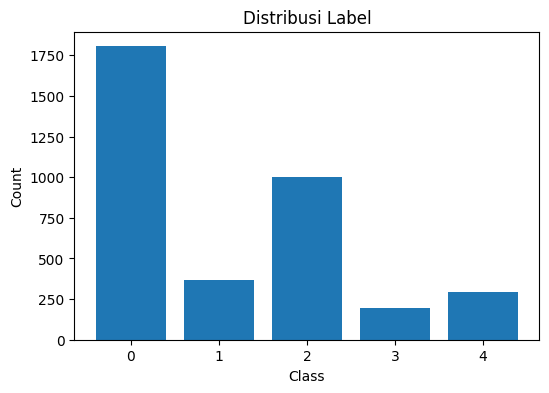

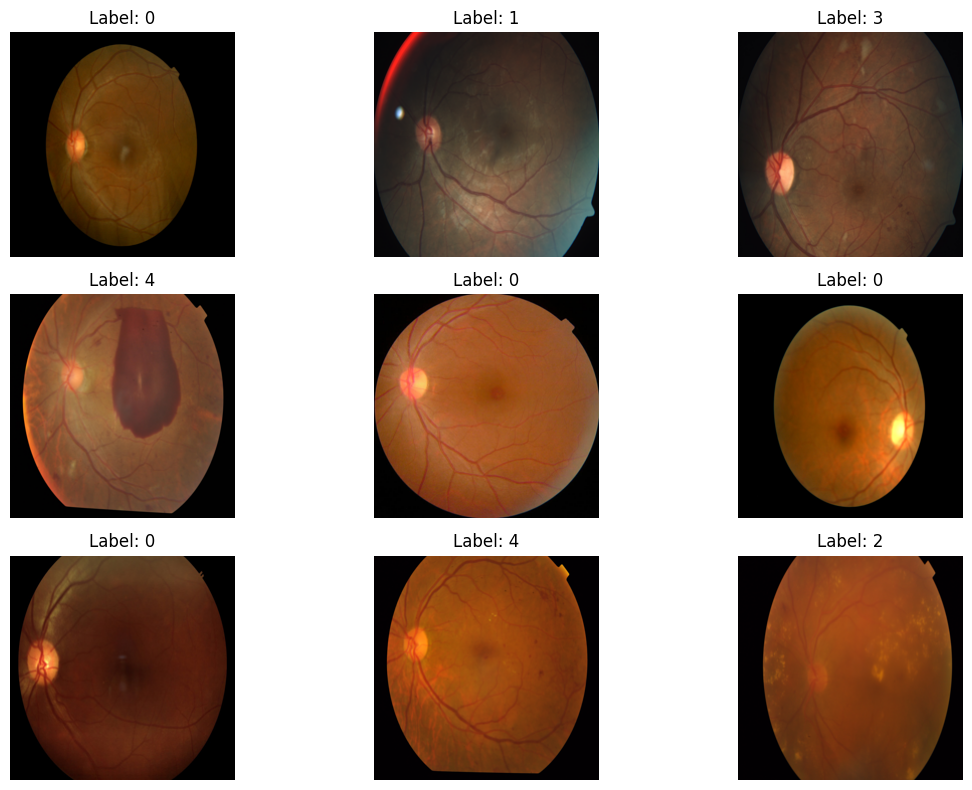

In [157]:
# =========================
# CELL 5 — EDA RINGAN + CEK DISTRIBUSI LABEL
# =========================
unique, counts = np.unique(y, return_counts=True)

print("Distribusi label:")
for cls, cnt in zip(unique, counts):
    print(f"Kelas {cls}: {cnt} sampel")

plt.figure(figsize=(6, 4))
plt.bar(unique.astype(str), counts)
plt.title("Distribusi Label")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Tampilkan beberapa sample
plt.figure(figsize=(12, 8))
sample_idxs = np.random.choice(len(X), size=min(9, len(X)), replace=False)

for i, idx in enumerate(sample_idxs, 1):
    plt.subplot(3, 3, i)
    img = X[idx]

    if img.max() > 1.5:
        plt.imshow(img.astype(np.uint8))
    else:
        plt.imshow(img)

    plt.title(f"Label: {y[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Distribusi label:
Kelas 0: 1805 sampel
Kelas 1: 370 sampel
Kelas 2: 999 sampel
Kelas 3: 193 sampel
Kelas 4: 295 sampel


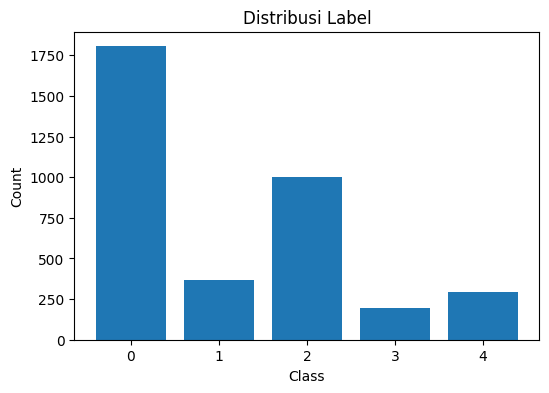

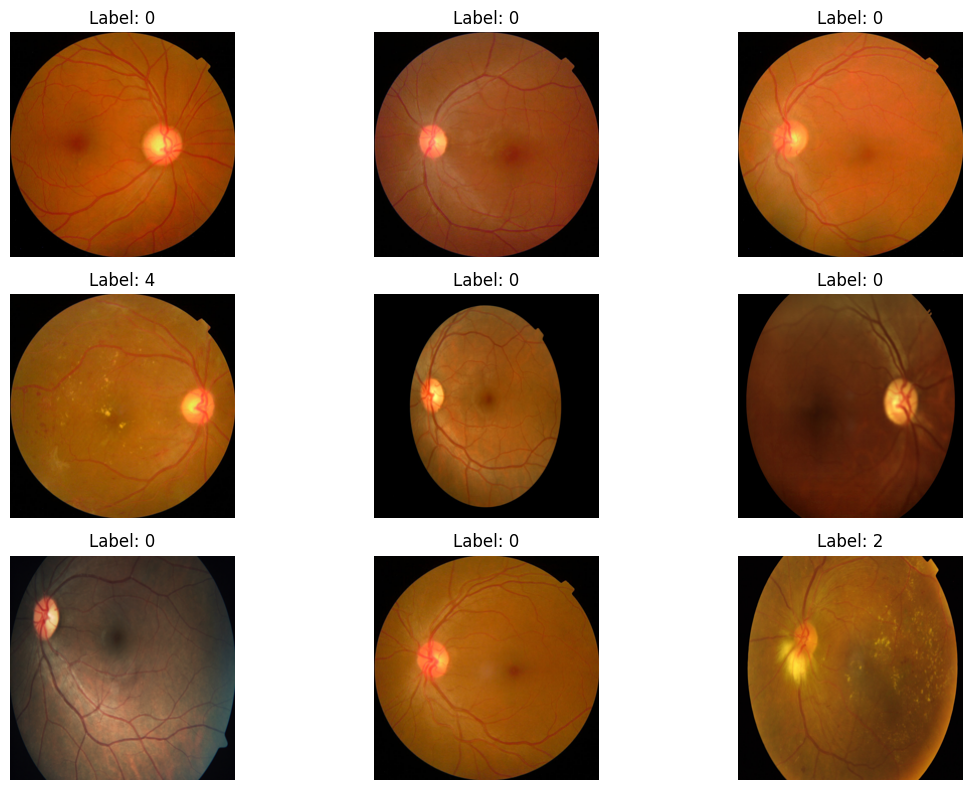

In [158]:
# =========================
# CELL 5 — EDA RINGAN + CEK DISTRIBUSI LABEL
# =========================
unique, counts = np.unique(y, return_counts=True)

print("Distribusi label:")
for cls, cnt in zip(unique, counts):
    print(f"Kelas {cls}: {cnt} sampel")

plt.figure(figsize=(6, 4))
plt.bar(unique.astype(str), counts)
plt.title("Distribusi Label")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Tampilkan beberapa sample
plt.figure(figsize=(12, 8))
sample_idxs = np.random.choice(len(X), size=min(9, len(X)), replace=False)

for i, idx in enumerate(sample_idxs, 1):
    plt.subplot(3, 3, i)
    img = X[idx]

    if img.max() > 1.5:
        plt.imshow(img.astype(np.uint8))
    else:
        plt.imshow(img)

    plt.title(f"Label: {y[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [159]:
# =========================
# CELL 6 — TRAIN/VAL SPLIT + CLIENT PARTITION (RATIO 1:2:3)
# =========================
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("GLOBAL SPLIT")
print("Train full:", X_train_full.shape, y_train_full.shape)
print("Val       :", X_val.shape, y_val.shape)

# rasio client = 1:2:3
client_ratios = [1, 2, 3]
total_ratio = sum(client_ratios)

n_total = len(X_train_full)
n_client1 = int(n_total * client_ratios[0] / total_ratio)
n_client2 = int(n_total * client_ratios[1] / total_ratio)
n_client3 = n_total - n_client1 - n_client2

print("\nTARGET CLIENT SIZES")
print("Client 1:", n_client1)
print("Client 2:", n_client2)
print("Client 3:", n_client3)

X_client1, X_rem, y_client1, y_rem = train_test_split(
    X_train_full, y_train_full,
    train_size=n_client1,
    random_state=SEED,
    stratify=y_train_full
)

client2_fraction_of_remaining = n_client2 / len(X_rem)

X_client2, X_client3, y_client2, y_client3 = train_test_split(
    X_rem, y_rem,
    train_size=client2_fraction_of_remaining,
    random_state=SEED,
    stratify=y_rem
)

print("\nACTUAL CLIENT SPLIT")
print("Client 1:", X_client1.shape, y_client1.shape)
print("Client 2:", X_client2.shape, y_client2.shape)
print("Client 3:", X_client3.shape, y_client3.shape)
print("Val     :", X_val.shape, y_val.shape)

GLOBAL SPLIT
Train full: (2929, 224, 224, 3) (2929,)
Val       : (733, 224, 224, 3) (733,)

TARGET CLIENT SIZES
Client 1: 488
Client 2: 976
Client 3: 1465

ACTUAL CLIENT SPLIT
Client 1: (488, 224, 224, 3) (488,)
Client 2: (976, 224, 224, 3) (976,)
Client 3: (1465, 224, 224, 3) (1465,)
Val     : (733, 224, 224, 3) (733,)


In [160]:
# =========================
# CELL 7 — CEK DISTRIBUSI LABEL PER CLIENT
# =========================
def show_distribution(labels, name):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name}")
    total = len(labels)
    for cls, cnt in zip(unique, counts):
        pct = 100 * cnt / total
        print(f"  Kelas {cls}: {cnt} ({pct:.2f}%)")

show_distribution(y_client1, "Client 1")
show_distribution(y_client2, "Client 2")
show_distribution(y_client3, "Client 3")
show_distribution(y_val, "Validation Global")


Client 1
  Kelas 0: 241 (49.39%)
  Kelas 1: 49 (10.04%)
  Kelas 2: 133 (27.25%)
  Kelas 3: 26 (5.33%)
  Kelas 4: 39 (7.99%)

Client 2
  Kelas 0: 481 (49.28%)
  Kelas 1: 99 (10.14%)
  Kelas 2: 266 (27.25%)
  Kelas 3: 51 (5.23%)
  Kelas 4: 79 (8.09%)

Client 3
  Kelas 0: 722 (49.28%)
  Kelas 1: 148 (10.10%)
  Kelas 2: 400 (27.30%)
  Kelas 3: 77 (5.26%)
  Kelas 4: 118 (8.05%)

Validation Global
  Kelas 0: 361 (49.25%)
  Kelas 1: 74 (10.10%)
  Kelas 2: 200 (27.29%)
  Kelas 3: 39 (5.32%)
  Kelas 4: 59 (8.05%)


In [161]:
# =========================
# CELL 8 — CLASS WEIGHT PER CLIENT
# =========================
def make_class_weights(y_data):
    classes = np.unique(y_data)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_data
    )
    return {int(c): float(w) for c, w in zip(classes, weights)}

class_weights_client1 = make_class_weights(y_client1)
class_weights_client2 = make_class_weights(y_client2)
class_weights_client3 = make_class_weights(y_client3)

print("Class weights Client 1:", class_weights_client1)
print("Class weights Client 2:", class_weights_client2)
print("Class weights Client 3:", class_weights_client3)

Class weights Client 1: {0: 0.4049792531120332, 1: 1.9918367346938775, 2: 0.7338345864661654, 3: 3.753846153846154, 4: 2.5025641025641026}
Class weights Client 2: {0: 0.40582120582120584, 1: 1.9717171717171718, 2: 0.7338345864661654, 3: 3.827450980392157, 4: 2.470886075949367}
Class weights Client 3: {0: 0.40581717451523547, 1: 1.9797297297297298, 2: 0.7325, 3: 3.8051948051948052, 4: 2.483050847457627}


In [162]:
# =========================
# CELL 9 — BUILD TF.DATA PIPELINE PER CLIENT
# =========================
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(images, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((images, labels))

    if training:
        ds = ds.shuffle(buffer_size=len(images), seed=SEED)

    def preprocess_fn(img, label):
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        label = tf.cast(label, tf.int32)
        return img, label

    ds = ds.map(preprocess_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds_client1 = make_dataset(X_client1, y_client1, training=True)
train_ds_client2 = make_dataset(X_client2, y_client2, training=True)
train_ds_client3 = make_dataset(X_client3, y_client3, training=True)

val_ds = make_dataset(X_val, y_val, training=False)

print("train_ds_client1:", train_ds_client1)
print("train_ds_client2:", train_ds_client2)
print("train_ds_client3:", train_ds_client3)
print("val_ds          :", val_ds)

train_ds_client1: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
train_ds_client2: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
train_ds_client3: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
val_ds          : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [163]:
# =========================
# CELL 10 — BUILD MODEL MOBILENETV2
# =========================
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
    ],
    name="data_augmentation",
)

def build_mobilenetv2_model(input_shape=(224, 224, 3), num_classes=5):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model, base_model

model, base_model = build_mobilenetv2_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,428,229 (9.26 MB)

 Trainable params: 167,429 (654.02 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [164]:
print(type(model))
print(type(base_model))

<class 'keras.src.models.functional.Functional'>
<class 'keras.src.models.functional.Functional'>


In [165]:
# =========================
# CELL 11 — COMPILE STAGE 1
# =========================
STAGE1_BEST_PATH = os.path.join(MODELS_DIR, "best_mobilenetv2_stage1.keras")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_STAGE1),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=STAGE1_BEST_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [166]:
# =========================
# CELL 12 — TRAIN STAGE 1
# =========================
history_stage1 = model.fit(
    train_ds_client1,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    class_weight=class_weights_client1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2937 - loss: 2.2056
Epoch 1: val_loss improved from None to 1.19297, saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet/models/best_mobilenetv2_stage1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet/models/best_mobilenetv2_stage1.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step - accuracy: 0.4119 - loss: 2.0267 - val_accuracy: 0.5089 - val_loss: 1.1930 - learning_rate: 0.0010
Epoch 2/20
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5972 - loss: 1.2890
Epoch 2: val_loss improved from 1.19297 to 1.06741, saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet/models/best_mobilenetv2_stage1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mob

In [167]:
# =========================
# CELL 13 — FINE-TUNING SETUP
# =========================
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print("Total layers in base model:", len(base_model.layers))
print("Fine-tune from layer index:", fine_tune_at)

Total layers in base model: 154
Fine-tune from layer index: 124


In [168]:
# =========================
# CELL 14 — COMPILE STAGE 2
# =========================
STAGE2_BEST_PATH = os.path.join(MODELS_DIR, "best_mobilenetv2_finetune.keras")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE_STAGE2),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

callbacks_stage2 = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=STAGE2_BEST_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [169]:
# =========================
# CELL 15 — TRAIN STAGE 2
# =========================
history_stage2 = model.fit(
    train_ds_client1,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    class_weight=class_weights_client1,
    callbacks=callbacks_stage2,
    verbose=1
)

Epoch 1/30
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5541 - loss: 1.4142
Epoch 1: val_loss improved from None to 0.90416, saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet/models/best_mobilenetv2_finetune.keras

Epoch 1: finished saving model to /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet/models/best_mobilenetv2_finetune.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 336ms/step - accuracy: 0.5328 - loss: 1.4182 - val_accuracy: 0.6548 - val_loss: 0.9042 - learning_rate: 1.0000e-05
Epoch 2/30
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.5802 - loss: 1.3740
Epoch 2: val_loss did not improve from 0.90416
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step - accuracy: 0.5533 - loss: 1.3942 - val_accuracy: 0.6439 - val_loss: 0.9319 - learning_rate: 1.0000e-05
Epoch 3/30
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6159 - loss: 1.0433
Epoch 3: ReduceLROnPlateau reduci

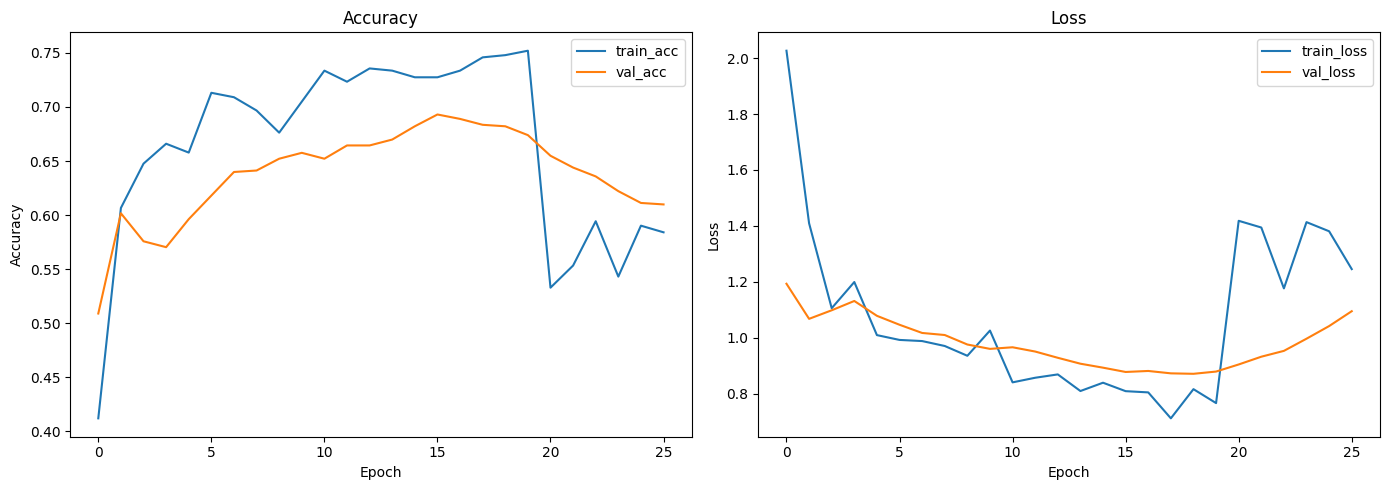

Training history figure saved to: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet/figures/training_history.png


In [170]:
# =========================
# CELL 16 — PLOT TRAINING HISTORY
# =========================
def plot_history(histories, titles=None, save_path=None):
    if not isinstance(histories, list):
        histories = [histories]
    if titles is None:
        titles = [f"History {i+1}" for i in range(len(histories))]

    all_acc = []
    all_val_acc = []
    all_loss = []
    all_val_loss = []

    for hist in histories:
        all_acc.extend(hist.history.get("accuracy", []))
        all_val_acc.extend(hist.history.get("val_accuracy", []))
        all_loss.extend(hist.history.get("loss", []))
        all_val_loss.extend(hist.history.get("val_loss", []))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(all_acc, label="train_acc")
    plt.plot(all_val_acc, label="val_acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(all_loss, label="train_loss")
    plt.plot(all_val_loss, label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()

history_plot_path = os.path.join(FIGURES_DIR, "training_history.png")
plot_history([history_stage1, history_stage2], ["Stage 1", "Stage 2"], save_path=history_plot_path)

print("Training history figure saved to:", history_plot_path)

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step
Classification Report:

              precision    recall  f1-score   support

           0     0.9550    0.8809    0.9164       361
           1     0.3465    0.5946    0.4378        74
           2     0.6691    0.4550    0.5417       200
           3     0.1333    0.3590    0.1944        39
           4     0.4062    0.2203    0.2857        59

    accuracy                         0.6548       733
   macro avg     0.5020    0.5020    0.4752       733
weighted avg     0.7277    0.6548    0.6767       733



<Figure size 800x600 with 0 Axes>

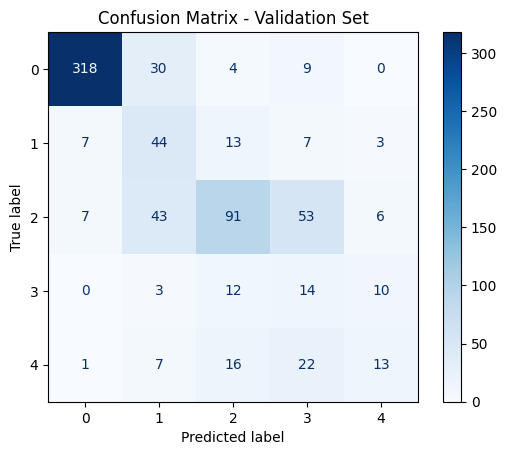

Confusion matrix figure saved to: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet/figures/confusion_matrix.png


In [171]:
# =========================
# CELL 17 — EVALUASI VALIDATION SET
# =========================
val_probs = model.predict(val_ds, verbose=1)
val_preds = np.argmax(val_probs, axis=1)

print("Classification Report:\n")
print(classification_report(y_val, val_preds, digits=4))

cm = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Validation Set")

cm_plot_path = os.path.join(FIGURES_DIR, "confusion_matrix.png")
plt.savefig(cm_plot_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Confusion matrix figure saved to:", cm_plot_path)

In [172]:
# =========================
# CELL 18 — SAVE MODEL FINAL
# =========================
FINAL_MODEL_PATH = os.path.join(MODELS_DIR, "mobilenetv2_aptos_final.keras")
model.save(FINAL_MODEL_PATH)

print("Model saved to:", FINAL_MODEL_PATH)

Model saved to: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet/models/mobilenetv2_aptos_final.keras


In [173]:
# =========================
# CELL 19 — SAVE TRAIN/VAL SPLIT INFO
# =========================
split_info = {
    "experiment_name": EXPERIMENT_NAME,
    "npz_path": NPZ_PATH,
    "train_size": int(len(X_client1)),
    "val_size": int(len(X_val)),
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES,
    "class_weights": class_weights_client1
}

split_info_path = os.path.join(LOGS_DIR, "mobilenetv2_run_info.json")

with open(split_info_path, "w") as f:
    json.dump(split_info, f, indent=4)

print("Run info saved to:", split_info_path)

Run info saved to: /content/drive/MyDrive/S-Class/Orion/OrionFL/orion-fl-dr-research/results/exp1_baseline/mobilenet/logs/mobilenetv2_run_info.json


In [174]:
# intentionally left blank